# Baseline Parameterization Training and Ensemble Runs

This notebook runs the experiment workflow end to end. It includes:

- generating L96 simulations,
- fitting simple parameterizations (no flows),
- running GCM simulations,
- and performing ensemble runs for both the GCM and L96 models.

The notebook is intended for exploratory use and method development.  
It is **not** optimized for large-scale experiments or production runs, but rather for testing configurations and gaining intuition about model behavior.


In [1]:
%autoreload

In [2]:
import sys
from pathlib import Path


# resolve project root (one level up from this notebook)
PROJECT_ROOT = Path.cwd().resolve().parents[0]

SRC_DIR = PROJECT_ROOT / "src"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for p in (SRC_DIR, NOTEBOOKS_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.polynomial.polynomial as poly

from config import Config
from ensemble.gcm_polynomial_ar_p_param import (
    run_poly_ar_p_param_ensemble_parallel_multiprocessing as run_ar_p_ensemble,
)
from ensemble.gcm_polynomial_param import (
    run_poly_param_ensemble_parallel_multiprocessing as run_poly_ensemble,
)
from ensemble.l96_ensemble import run_l96_parallel
from models.execute import initialize_l96, run_gcm
from models.forcing_schedule import parse_forcing_schedule, forcing_at_array
from models.GCM.gcm import GCM
from models.L96.lorenz96 import L96
from parameterization.base_parameterization import BaseParameterization
from parameterization.baselines.fit_parameters import (
    fit_deterministic_poly_coefs,
)
from parameterization.baselines.polynomial_ar_p_parameterization import (
    PolynomialARpParameterization,
)
from parameterization.baselines.polynomial_parameterization import (
    PolynomialParameterization,
)
from parameterization.utils.helpers import compute_ar_p_noise, compute_coupling_from_x
from parameterization.utils.fit_ar_process import fit_baseline_poly_ar
from perturbations.iid import perturb_iid
from plotting.fit.contour import (
    plot_gcm_contour_comparison,
    plot_gcm_contour_difference,
)
from plotting.fit.distribution import (
    plot_x_u_distribution_with_polynomial_fit,
    plot_x_u_distribution_with_stochastic_polynomial_fit,
)
from plotting.fit.time_series import (
    plot_gcm_time_series_comparison,
    plot_residuals_with_noise,
)
from plotting.lorenz96.contour import plot_l96_x_and_y
from plotting.lorenz96.time_series import plot_l96_x_with_random_y


### Parameter settings


In [4]:
cfg = Config(
    {
        "K": 8,  # Number of global-scale variables X
        "J": 32,  # Number of local-scale Y variables per single global-scale X variable
        "h": 1.0,  # Coupling coefficient
        "F": 20.0,  # Forcing
        "b": 10.0,  # spatial-scale ratio
        "c": 10.0,  # time-scale ratio
        "seed": 42,
        "y_scale": 1.0,  # scaling factor for the Y variables when switching between Crommeling and Arnold L96 formulations
    }
)
cfg.forcing_schedule = parse_forcing_schedule(cfg.F)

In [5]:
total_time_l96 = 300
total_time_ens = 10

## Truth simulation: Two time-scale L96


In [6]:
cfg.si = 0.005
cfg.dt = 1e-3
cfg.total_time = total_time_l96
cfg.train_perc = 1.0
cfg.spin_up_time = 20

In [7]:
m = L96(
    cfg.K,
    cfg.J,
    F_schedule=cfg.forcing_schedule,
    h=cfg.h,
    b=cfg.b,
    c=cfg.c,
    seed=cfg.seed,
)
# Spin up model
# `store=True` saves the final state as an initial condition for the next run.
x, y, t = m.run(si=cfg.si, total_time=cfg.spin_up_time, dt=cfg.dt, store=True)
init_conditions = m.x

In [8]:
# Run the model and return the true coupling term u
x_true, y_true, t = m.run(cfg.si, cfg.total_time, dt=cfg.dt, store=True)

### Plots


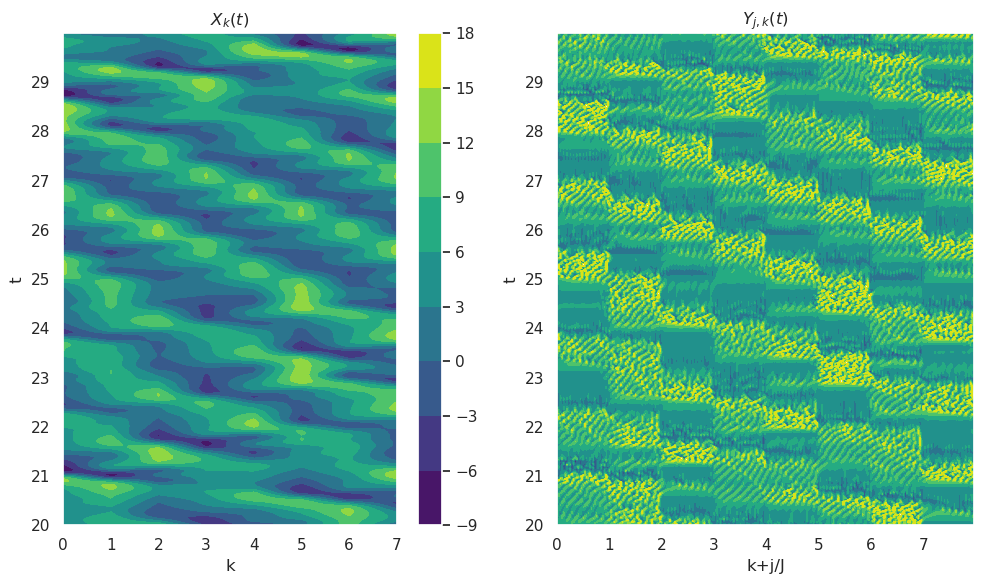

In [9]:
time_end = 2000
fig = plot_l96_x_and_y(x_true, y_true, t, time_end)
plt.show()

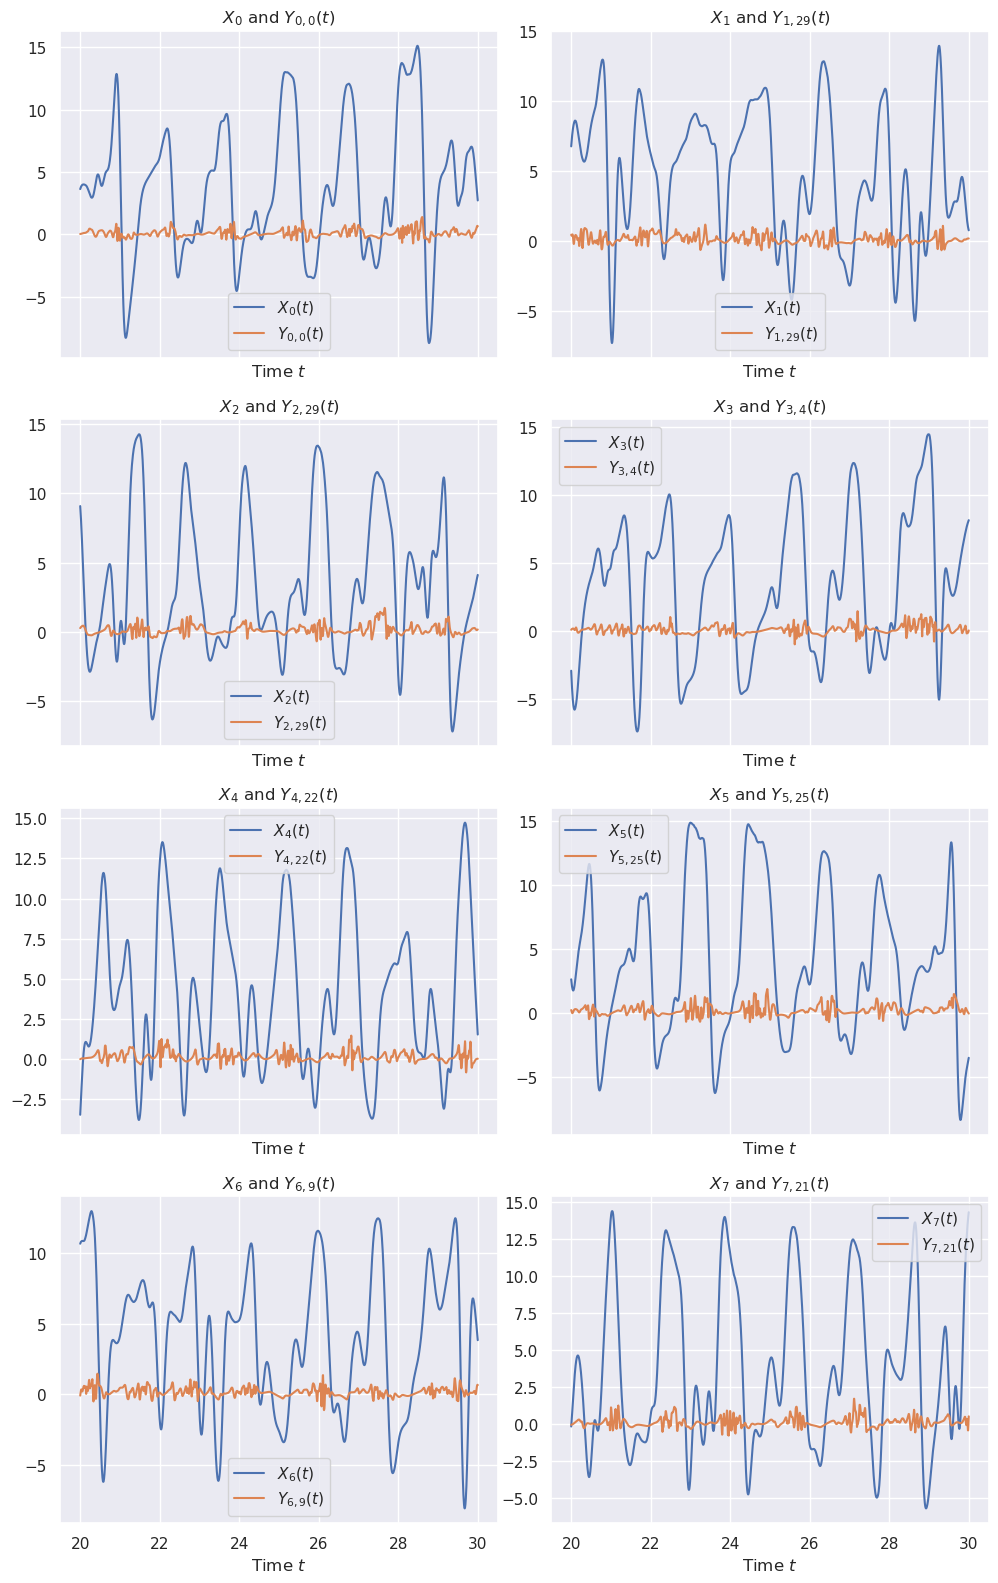

In [10]:
time_end = 2000

fig = plot_l96_x_with_random_y(x_true, y_true, t, time_end, figsize=(10, 16), columns=2)
plt.show()

### Select training data


In [11]:
train_index = int(cfg.train_perc * x_true.shape[0])

F_values = forcing_at_array(cfg.forcing_schedule, t)
u_train, x_train = compute_coupling_from_x(
    x_true[:train_index], cfg.si, F_values[:train_index], cfg.h, cfg.b, cfg.c
)
x_train.shape

(60000, 8)

## Deterministic parameterization


$U_p$ = Polynomial of order 3 (analogue to Arnold et al. 2013)


In [12]:
p3_coefs = fit_deterministic_poly_coefs(x_train, u_train, poly_order=3)
print(p3_coefs)

[ 0.33029105  1.30222942 -0.01246304 -0.00241735]


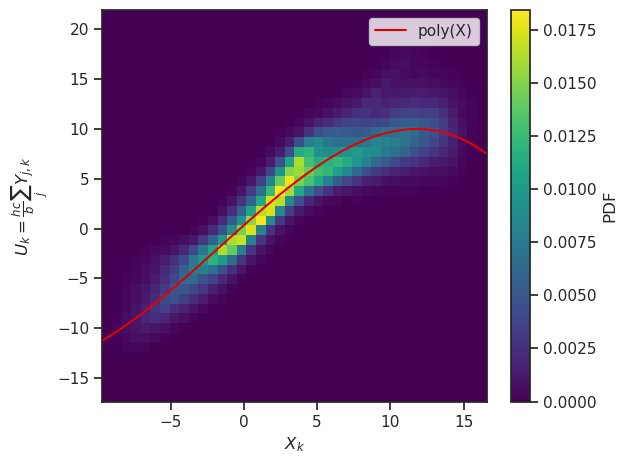

In [13]:
fig = plot_x_u_distribution_with_polynomial_fit(
    x_train,
    u_train,
    p3_coefs,
    poly_label="poly(X)",
)
plt.show()

## Stochastic parameterization


Analogue to Arnold et al. 2013:

$U_p = U_{det} + e(t)$

Model $e(t)$ as a first-order autoregressive (AR(1)) process:

$e(t) = \phi e(t-\Delta t) + \sigma_e (1 - \phi^2)^{1/2} z(t)$


In [14]:
rho, sigma = fit_baseline_poly_ar(
    x_train,
    u_train,
    p3_coefs,
    p=1,
    method="least_squares",
)


### Plots


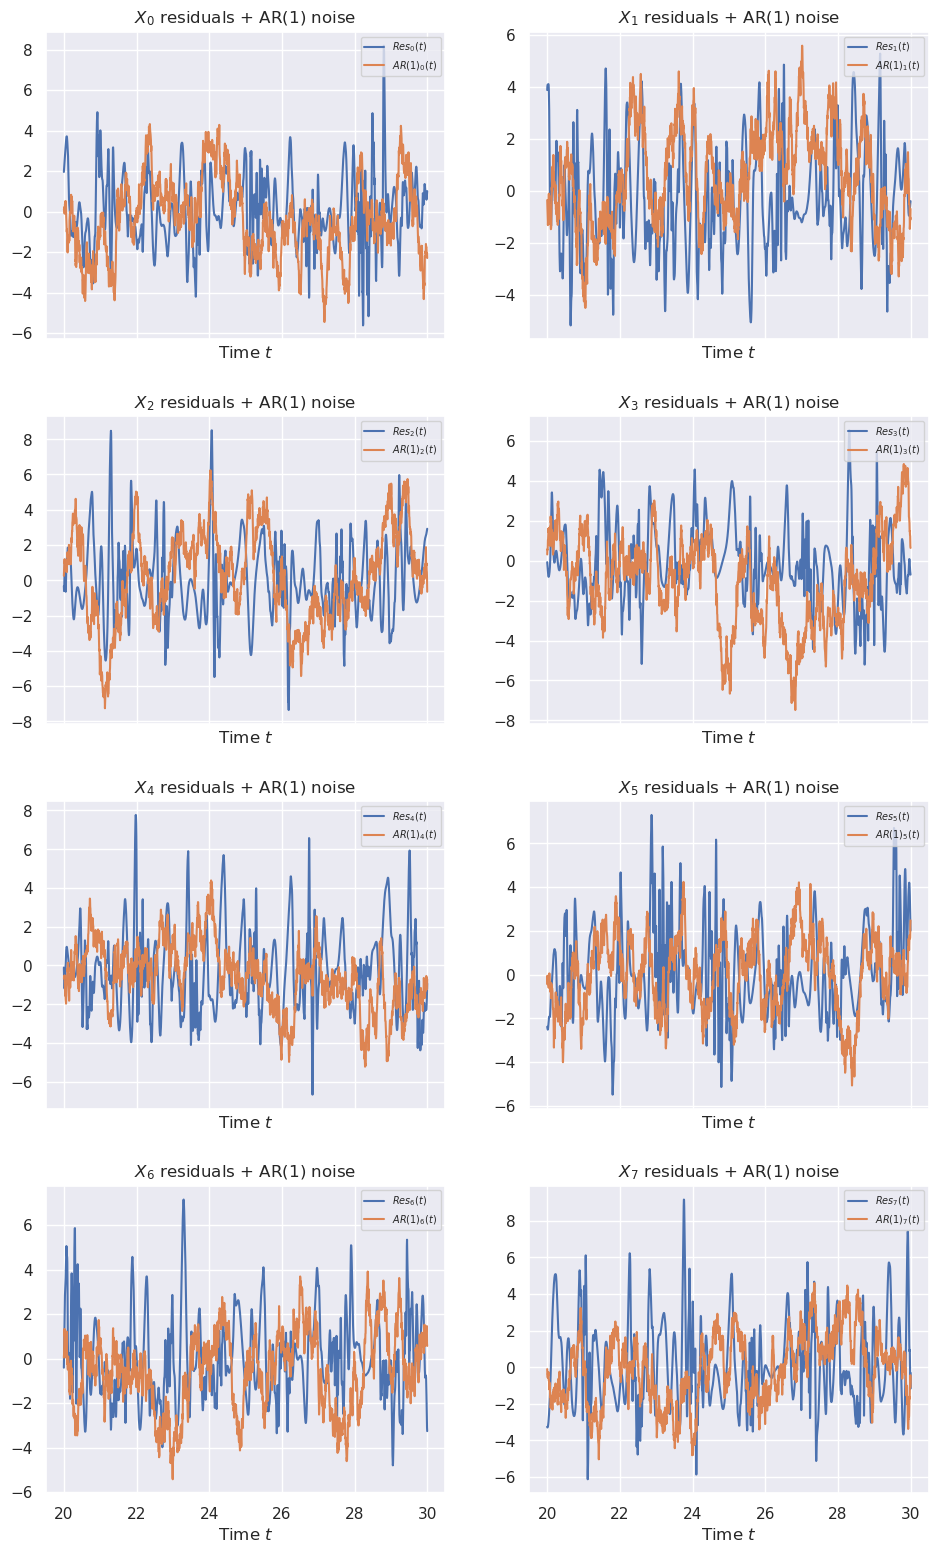

In [15]:
time_end = 2000

residuals = u_train - poly.polyval(x_train, p3_coefs)
ar1_noise = compute_ar_p_noise(
    rho, sigma, steps=u_train.shape[0], k=cfg.K, seed=cfg.seed
)

plot_residuals_with_noise(
    residuals,
    ar1_noise,
    t,
    time_end,
    figsize=(10, 16),
    columns=2,
)
plt.show()

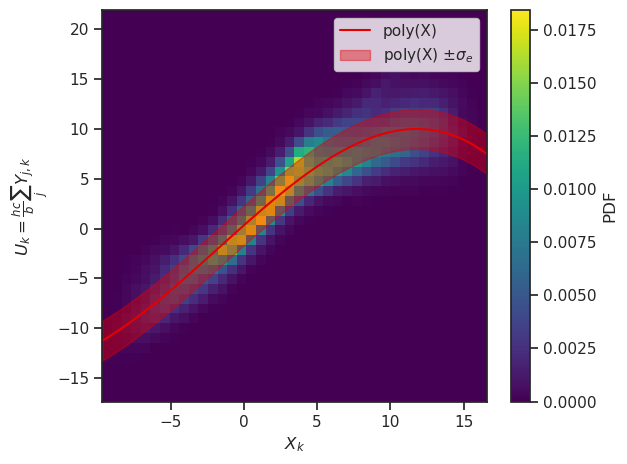

In [16]:
fig = plot_x_u_distribution_with_stochastic_polynomial_fit(
    x_train,
    u_train,
    p3_coefs,
    rho,
    sigma,
    poly_label="poly(X)",
    seed=cfg.seed,
)

plt.show()

## GCM run with parameterization


In [17]:
cfg.time_stepping = "RK2"
cfg.total_time = total_time_l96


### Without parameterization


In [18]:
# Zero parameterization
class ZeroParam(BaseParameterization):
    def update(self):
        pass

    def predict(self, x, F):
        return 0


In [19]:
gcm_no_param = GCM(ZeroParam(), F_schedule=cfg.forcing_schedule)
x_no_param, t_no_param = run_gcm(gcm_no_param, init_conditions, cfg)

### Deterministic parameterization


In [20]:
det_param = PolynomialParameterization(p3_coefs)

In [21]:
gcm_det_param = GCM(det_param, F_schedule=cfg.forcing_schedule)
x_det_param, t_det_param = run_gcm(gcm_det_param, init_conditions, cfg)

### Stochastic parameterization


In [22]:
stochastic_param = PolynomialARpParameterization(p3_coefs, rho, sigma, seed=cfg.seed)

In [23]:
gcm_stoch_param = GCM(stochastic_param, F_schedule=cfg.forcing_schedule)
x_stoch_param, t_stoch_param = run_gcm(gcm_stoch_param, init_conditions, cfg)

### Plots


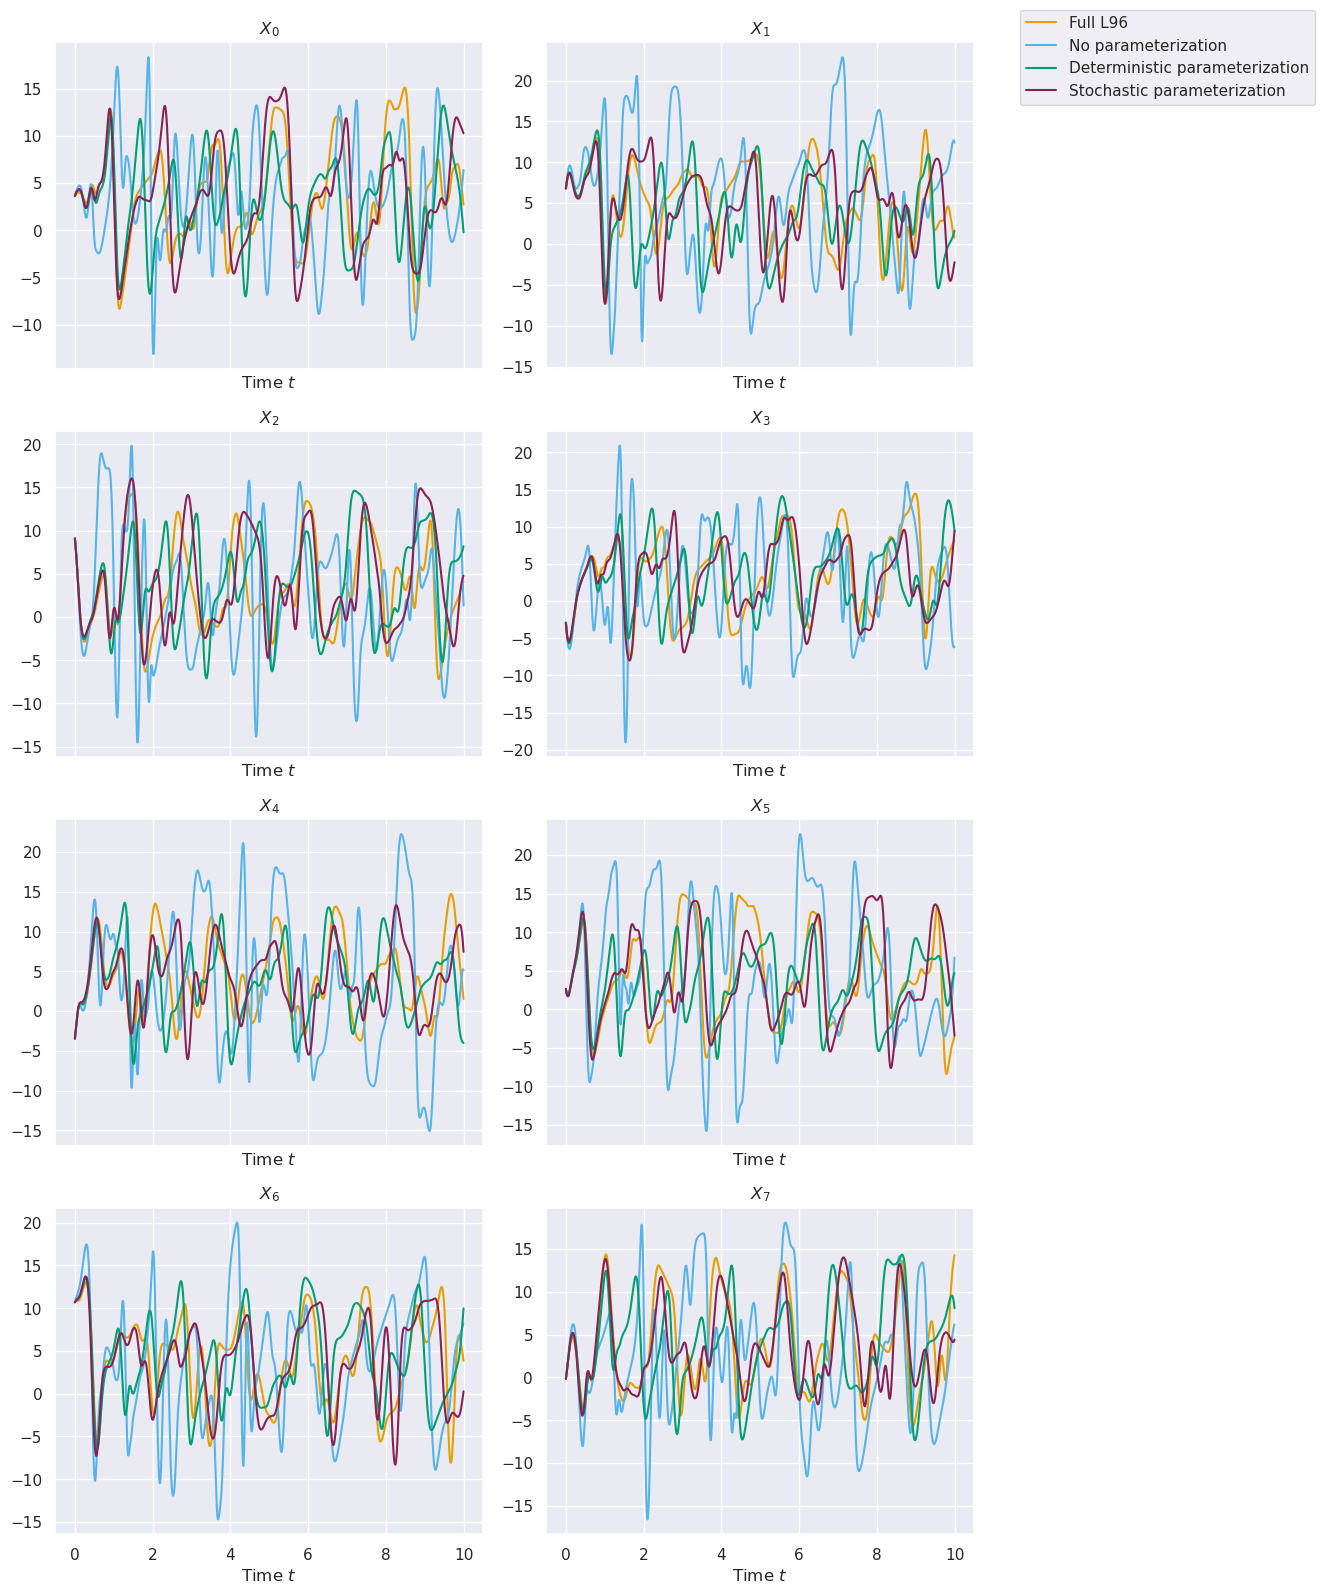

In [24]:
time_end = int(10 / cfg.si)
x_data = {
    "full": x_true,
    "no_param": x_no_param,
    "det_param": x_det_param,
    "stoch_param": x_stoch_param,
}
fig = plot_gcm_time_series_comparison(
    t_no_param,
    x_data,
    time_end,
    time_start=0,
    figsize=(10, 16),
    columns=2,
)
plt.show()

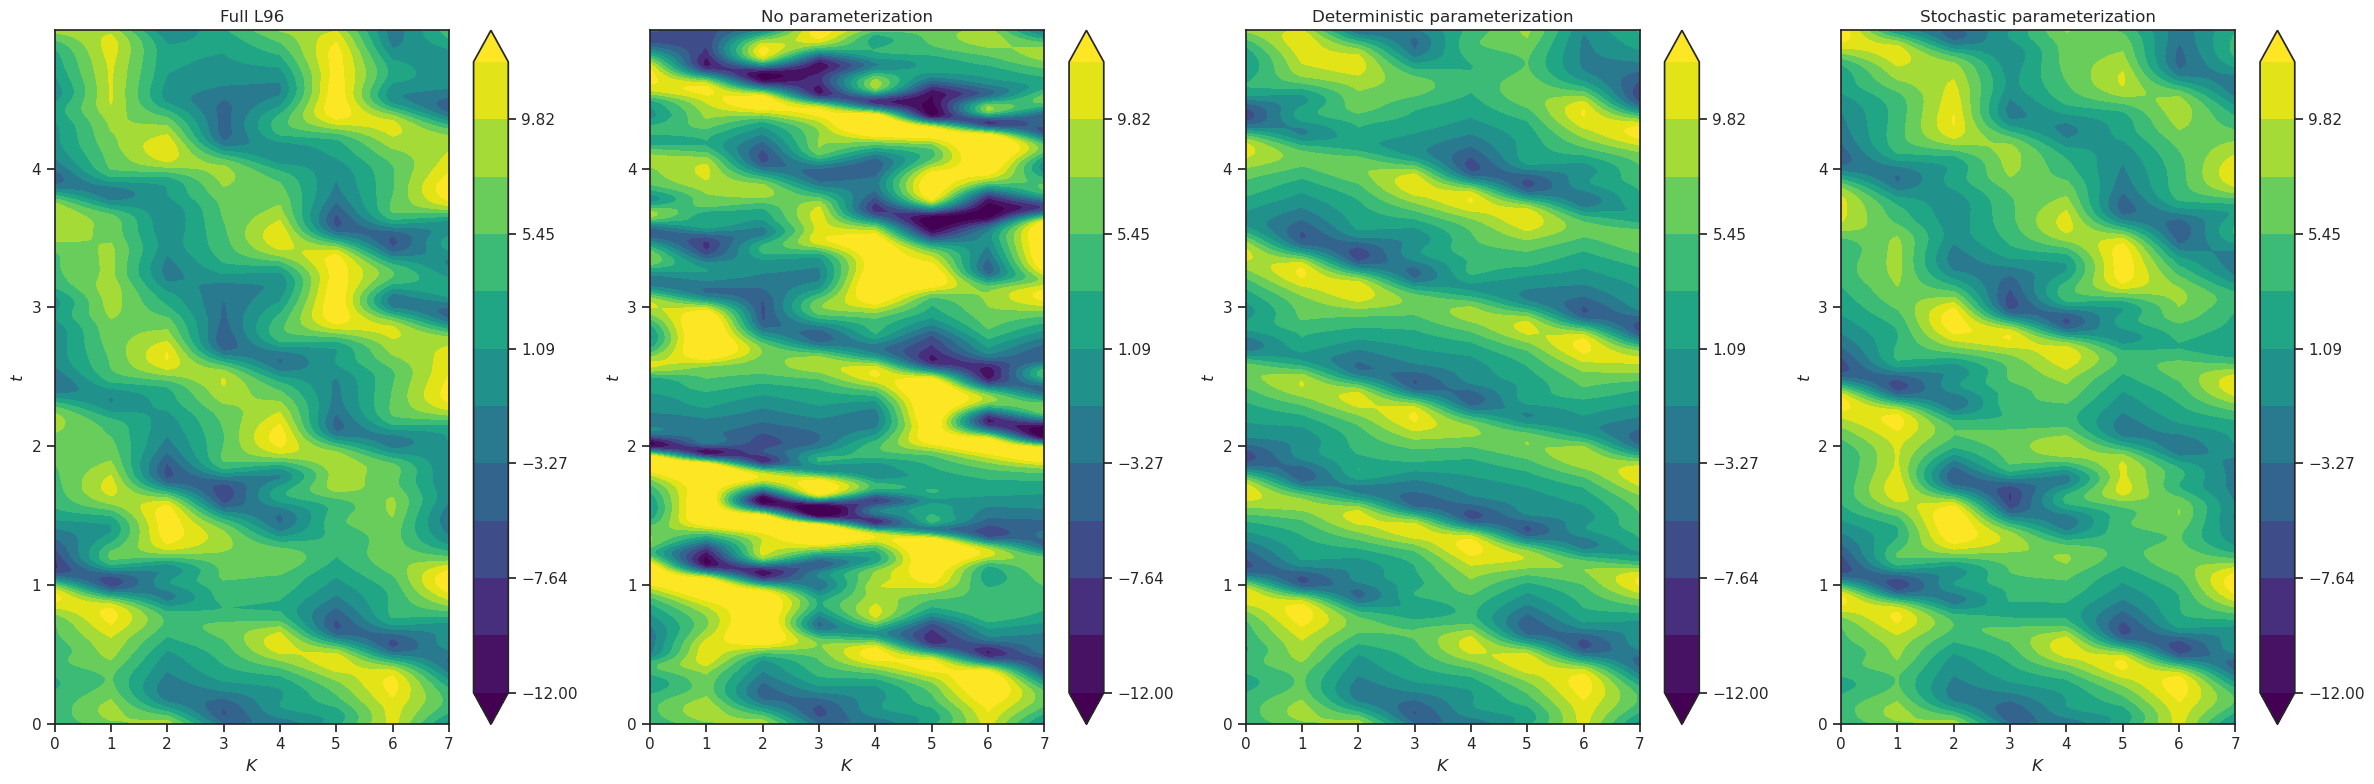

In [25]:
time_end = 1000
fig = plot_gcm_contour_comparison(
    t_no_param,
    x_data,
    time_end,
    time_start=0,
    max_ncols=4,
)
plt.show()


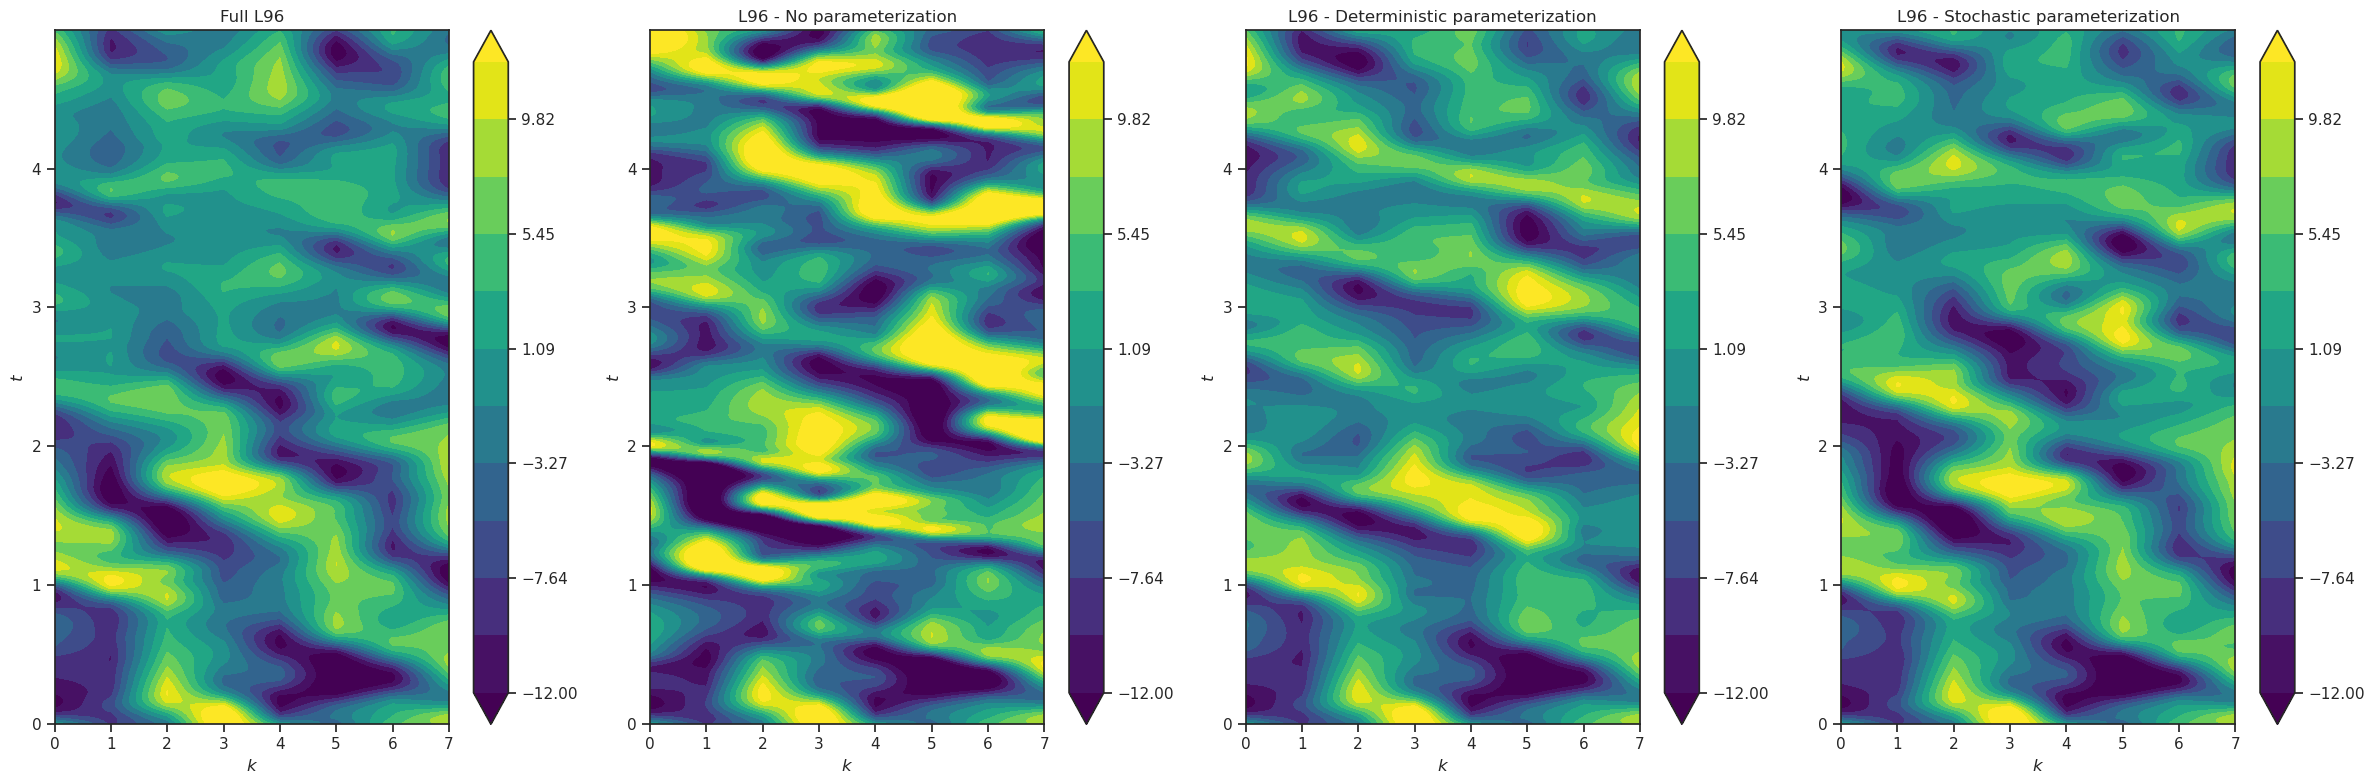

In [26]:
time_end = 1000
fig = plot_gcm_contour_difference(
    t_no_param,
    x,
    x_data,
    time_end,
    time_start=0,
    max_ncols=4,
)
plt.show()


## Ensemble run


### Generate initial states


In [27]:
num_init_states = 3
num_ensemble_members = 2
num_models = 1

In [28]:
state_step = 20
generation_time = num_init_states * state_step
cfg.spin_up_time = 20

In [29]:
# Get perfect initital states from the true trajectory
init_states_x = np.zeros((num_init_states, cfg.K))
init_states_y = np.zeros((num_init_states, cfg.K * cfg.J))
init_states_t = np.zeros((num_init_states,))

l = initialize_l96(cfg)
x, y, t = l.run(si=cfg.si, dt=cfg.dt, total_time=generation_time)

In [30]:
# Select perfect states
step_int = int(state_step / cfg.si)
init_states_x = x[:-1:step_int]
init_states_y = y[:-1:step_int]
init_states_t = t[:-1:step_int]

# Perturb them
perturb_std = 0.25
rng = np.random.default_rng(cfg.seed)
init_states_x = perturb_iid(init_states_x, num_ensemble_members, perturb_std, rng)
init_states_y = perturb_iid(init_states_y, num_ensemble_members, perturb_std, rng)


In [31]:
# Broadcast initial states to shape (n_init_states, n_ens_members, 1, K) for use in ensemble runs
init_states_x = np.broadcast_to(
    init_states_x[:, :, None, :],
    (num_init_states, num_ensemble_members, num_models, cfg.K),
).copy()
init_states_y = np.broadcast_to(
    init_states_y[:, :, None, :],
    (num_init_states, num_ensemble_members, num_models, cfg.K * cfg.J),
).copy()

### Run ensembles


In [32]:
cfg.total_time = total_time_ens
# Number of initial states
cfg.n_init_states = num_init_states
# Number of ensemble members
cfg.n_ens_members = num_ensemble_members
cfg.n_models = num_models


#### Deterministic polynomial baseline


In [33]:
x_det_ens, t_det_ens = run_poly_ensemble(
    init_states_x,
    cfg,
    p3_coefs,
    num_processes=1,
)

#### Stochastic polynomial + AR(1) parameterization


In [34]:
# This is the mix settings were we mix stochastic model realizations with perturbations
ar1_seeds = np.arange(
    cfg.seed + 1,
    cfg.seed + (cfg.n_init_states * cfg.n_ens_members) + 1,
    dtype=int,
).reshape(cfg.n_init_states, cfg.n_ens_members, cfg.n_models)

x_stoch_ens, t_stoch_ens = run_ar_p_ensemble(
    init_states_x,
    cfg,
    p3_coefs,
    rho,
    sigma,
    ar1_seeds,
    num_processes=1,
)


#### L96 ensemble


In [35]:
# L96 doesn't know the model dimension, so we remove it
init_x_l96 = np.squeeze(init_states_x, axis=2)
init_y_l96 = np.squeeze(init_states_y, axis=2)
x_l96_ens, y_l96_ens, t_l96_ens = run_l96_parallel(
    init_x_l96, init_y_l96, cfg, num_processes=1
)